# 카메라영상분류

카메라 프레임에서 모델이 볼 영역을 직접 만들고 실제 예측에 연결합니다.

함수명·입출력·API 예시는 제공합니다. **작성 구간의 처리 로직을 직접 구성하세요.**
검증 셀은 수정하지 않습니다. 파일 안에서는 위에서부터 실행합니다.


In [2]:
from pathlib import Path
import os, sys, json, time

# root 자동 탐색 코드
# ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p/'signlab.py').exists()), None)
# if ROOT is None: raise RuntimeError('오전_최종본 폴더에서 실행하세요.')

# 기존 자동 탐색 코드를 지우고, 확인된 절대 경로를 직접 주입합니다.  - 00 오전 실습 준비에서 위치 찾아서 수정
ROOT = Path(r"C:\Users\User\.ngv_day4_2026\am\9de5e80f5a44")

sys.path.insert(0,str(ROOT))
os.environ['MPLCONFIGDIR']=str(ROOT/'.runtime/matplotlib')
os.environ['YOLO_CONFIG_DIR']=str(ROOT/'.runtime/yolo')
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance, ImageOps, ImageDraw
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
torch.set_num_threads(4)
plt.rcParams['font.family']='Malgun Gothic'
plt.rcParams['axes.unicode_minus']=False
import signlab as lab
data=lab.load_data()
NAMES=lab.NAMES_KO

import cv2


## 입력 변환과 모델 선택 · 제공 코드
01 입력 변환을 재사용합니다. auto는 02에서 검증으로 선택한 모델, 02 증강 모델, 01 학생 모델, 제공 모델 순서로 선택합니다.
`student`, `baseline`, `augmented`, `provided`로 직접 선택할 수도 있습니다.
중앙 영역의 8종 분류이며 위치 탐지·미지 클래스 판별은 하지 않습니다.

In [3]:
def make_batch(images,color_order='RGB'):
    tensors=[]
    for pixels in images:
        rgb=pixels if color_order=='RGB' else pixels[:,:,::-1]
        tensor=torch.from_numpy(np.array(rgb,copy=True,order="C")).float().permute(2,0,1)/255
        tensors.append((tensor-.5)/.5)
    return torch.stack(tensors)
MODEL_SOURCE='auto'  # auto / student / baseline / augmented / provided
model_dir=ROOT/'outputs/student_model'
assert MODEL_SOURCE in ['auto','student','baseline','augmented','provided']
files={'student':'latest.pt','baseline':'baseline.pt','augmented':'augmented.pt'}
labels={'student':'01 학생 설계 CNN','baseline':'02 직접 학습 기본 CNN','augmented':'02 직접 학습 증강 CNN','provided':'제공 밝기 증강 CNN'}
choice=MODEL_SOURCE
if choice=='auto':
    selection=model_dir/'selection.json'
    if selection.exists():choice=json.loads(selection.read_text(encoding='utf-8'))['key']
    elif (model_dir/'augmented.pt').exists():choice='augmented'
    elif (model_dir/'latest.pt').exists():choice='student'
    else:choice='provided'
if choice=='provided':model=lab.load_model(ROOT/'models/comparison/augmented/final.pt').eval()
else:
    model_path=model_dir/files[choice]
    if not model_path.exists():raise FileNotFoundError(f'{labels[choice]}이 없습니다. 해당 실습을 학습·저장한 뒤 선택하세요.')
    with model_path.open('rb') as file:model=torch.jit.load(file,map_location='cpu').eval()
MODEL_LABEL=labels[choice];MODEL_TAG=choice.upper()
from IPython.display import display,HTML
display(HTML(f'<h2 style="color:#2563eb">사용 모델 — {MODEL_LABEL}</h2>'))
print('모델 출처:',MODEL_LABEL)


모델 출처: 02 직접 학습 증강 CNN


## ✏️ A06 · 카메라 관심 영역과 모델 입력 구현

입력: BGR 프레임 `[H,W,3]`, 관심 영역 비율(0보다 크고 1 이하).
짧은 변×비율 길이의 중앙 정사각형을 자르고 RGB로 변환하세요. 자동 대비 보정 후 48×48 bilinear 크기로 맞춥니다.
반환: `[1,3,48,48]` 텐서, 전처리 PIL 그림, `(left,top,right,bottom)` 좌표. 오른쪽·아래쪽은 슬라이스 끝 좌표입니다. 원본은 변경하지 않습니다.

### 사용할 수 있는 API
`frame.shape`, NumPy 슬라이싱, `cv2.cvtColor(...,cv2.COLOR_BGR2RGB)`, `ImageOps.autocontrast`, `image.resize((48,48),Image.Resampling.BILINEAR)`, 앞 셀의 `make_batch`.
중앙 영역 시작 좌표는 전체 길이와 영역 길이의 차이로 구할 수 있습니다.


In [ ]:
# ===== 실습 A06 시작 =====

def prepare_frame(frame,roi_fraction=.6):
    h,w =frame.shape[:2] # 특정 영역을 자름 
    
    #채널은 rgb 값이기 때문에 자를때에는 고려할 필요가 없음

    side=max(1, int(min(h,w)*roi_fraction));left=(w-side)//2;top=(h-side)//2  # 어딜 자르게 될지 정하고 있음.
    rgb=cv2.cvtColor(frame [top:top+side,left:left+side], cv2.COLOR_BGR2RGB)
    prepared =ImageOps.autocontrast(Image.fromarray(rgb)).resize((48,48),Image.Resampling.BILINEAR)
    return make_batch([np.asarray(prepared)]),prepared,(left,top,left+side,top+side)
    #raise NotImplementedError('A06: 영역 선택과 전처리 구현')

# ===== 실습 A06 끝 =====


**A06 검증** · 아래 셀이 통과한 뒤 실제 데이터에 적용합니다.


In [9]:
rng=np.random.default_rng(7)
for h,w,fraction in [(100,180,.6),(180,100,.4),(63,91,1.)]:
    frame=rng.integers(0,256,(h,w,3),dtype=np.uint8);original=frame.copy()
    tensor,prepared,box=prepare_frame(frame,fraction)
    side=int(min(h,w)*fraction);left=(w-side)//2;top=(h-side)//2
    assert tuple(box)==(left,top,left+side,top+side),'A06: 세로·가로 프레임의 중앙 영역을 확인하세요.'
    rgb=frame[top:top+side,left:left+side,::-1]
    expected=ImageOps.autocontrast(Image.fromarray(rgb)).resize((48,48),Image.Resampling.BILINEAR)
    assert prepared.size==(48,48) and np.array_equal(np.asarray(prepared),np.asarray(expected))
    assert tensor.shape==(1,3,48,48) and torch.allclose(tensor,make_batch([np.asarray(expected)]))
    assert np.array_equal(frame,original)
print('A06 통과: 중앙 영역·RGB·크기·값·원본 보존')


A06 통과: 중앙 영역·RGB·크기·값·원본 보존


## 같은 입력에서 영역만 변경 · 제공 코드
영역을 너무 넓히거나 좁혔을 때 실제 모델 입력과 예측을 비교합니다. 높은 점수가 정답을 보장하지 않습니다.


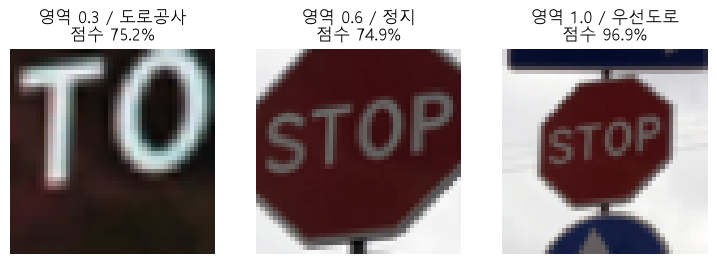

In [10]:
photo=Image.open(ROOT/'data/camera_example.png').convert('RGB').crop((170,80,245,155))
frame=cv2.cvtColor(np.asarray(photo),cv2.COLOR_RGB2BGR)
fig,axes=plt.subplots(1,3,figsize=(9,3))
for ax,fraction in zip(axes,[.3,.6,1.]):
    tensor,prepared,box=prepare_frame(frame,fraction)
    with torch.inference_mode():prob=model(tensor).softmax(1)[0]
    label=int(prob.argmax());ax.imshow(prepared);ax.axis('off');ax.set_title(f'영역 {fraction} / {NAMES[label]}\n점수 {float(prob[label]):.1%}')
plt.show()


## 기본·증강 모델 비교 · 제공 코드
02에서 저장한 두 모델에 같은 사진을 입력합니다. USB에서도 `MODEL_SOURCE`만 바꾸고 같은 표지판·조명·영역으로 비교하세요.

02 직접 학습 기본 CNN 정지 점수 99.6%
02 직접 학습 증강 CNN 정지 점수 74.9%


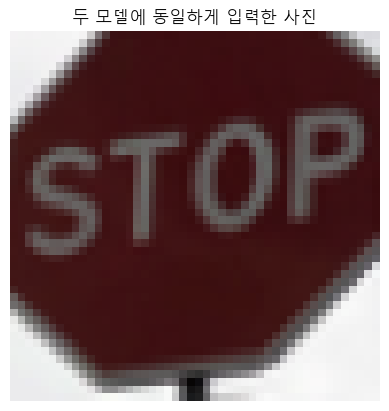

In [11]:
# 같은 프레임·같은 전처리를 두 모델에 적용합니다.
comparison_models={}
for key in ['baseline','augmented']:
    path=model_dir/files[key]
    if path.exists():
        with path.open('rb') as file:comparison_models[key]=torch.jit.load(file,map_location='cpu').eval()
photo=Image.open(ROOT/'data/camera_example.png').convert('RGB').crop((170,80,245,155))
frame=cv2.cvtColor(np.asarray(photo),cv2.COLOR_RGB2BGR)
tensor,prepared,box=prepare_frame(frame,.6)
if len(comparison_models)==2:
    for key,m in comparison_models.items():
        with torch.inference_mode():prob=m(tensor).softmax(1)[0]
        label=int(prob.argmax());print(labels[key],NAMES[label],f'점수 {float(prob[label]):.1%}')
    plt.imshow(prepared);plt.axis('off');plt.title('두 모델에 동일하게 입력한 사진');plt.show()
else:print('02를 직접 학습하면 기본·증강 모델을 같은 사진으로 비교할 수 있습니다.')

## USB 카메라 연결 · 제공 코드
읽기·표시·종료 처리는 제공합니다. 실제 입력 변환에는 작성한 `prepare_frame`을 사용합니다.
표지판 하나를 영역 안에 두고 `RUN_CAMERA=True`로 실행합니다. Q/Esc로 종료합니다.


In [12]:
RUN_CAMERA=False
CAMERA_INDEX=0
ROI_FRACTION=.6
if RUN_CAMERA:
    print('사용 모델:',MODEL_LABEL)
    cap=cv2.VideoCapture(CAMERA_INDEX)
    try:
        if not cap.isOpened():raise RuntimeError('카메라 연결·권한·다른 앱 사용 여부를 확인하세요.')
        while True:
            ok,frame=cap.read()
            if not ok:break
            tensor,prepared,box=prepare_frame(frame,ROI_FRACTION)
            with torch.inference_mode():prob=model(tensor).softmax(1)[0]
            label=int(prob.argmax());shown=frame.copy();left,top,right,bottom=box
            cv2.rectangle(shown,(left,top),(right,bottom),(0,255,0),2)
            cv2.putText(shown,f'{lab.NAMES[label]} {float(prob[label]):.2f}',(10,30),cv2.FONT_HERSHEY_SIMPLEX,.7,(0,255,0),2)
            cv2.putText(shown,MODEL_TAG,(10,60),cv2.FONT_HERSHEY_SIMPLEX,.65,(0,255,255),2)
            cv2.imshow('Sign classification - Q to quit',shown)
            if cv2.waitKey(1)&0xFF in [ord('q'),27]:break
    finally:cap.release();cv2.destroyAllWindows()
